# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print('Nulos:', '\n', users.isna().sum())
print('Proporcion:', '\n', users.isna().mean())


Nulos: 
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion: 
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print('Nulos:', '\n', usage.isna().sum())
print('Proporcion:', '\n', usage.isna().mean())

Nulos: 
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporcion: 
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users: city 11.7% y churn_date 88.3%
- En usage: date 0.1%, duration 55.1% y length 44.7%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- investigar e imputar city: me da segemento demografico
- imputar churn_date: me dice si el usuario esta activo o inactivo
- date: esta como texto, pasarlo a formato fecha
- investigar e imputar duration: para que no me afecte el costo y perfil de uso de llamadas
- investigar e imputar length: para que no me afecte el costo y perfil de uso de mensajes

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


Haz doble clic en este bloque y escribe qué ves.
- La columna `user_id` del usuario 10,000 al 13,999
- La columna `age` el promedio de edad es de 33-34 años, y el min de -999(error)

In [13]:
# explorar columnas numéricas de usage
usage[['user_id', 'id']].describe()

,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


Haz doble clic en este bloque y escribequé ves.
- La columna `id` del registro 1 al 40k
- La columna `user_id` del usuario 10k al 13,999, pero hay 40k registros, creo que se repiten

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()
print(columnas_user)

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene nulos, 7 ciudades unicas, bogota es el mas frecuente
- La columna `plan` el plan basico es el mas contratado

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` los mas usado son los mensajes de texto

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- columna city con nulos, age con edad minima -999, user_id repetidos
- ¿Qué acción tomarías?
- hay que investigar e imputar, reemplazar valores nulos, tomar medias en edades y revisar los user_id

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

haz doble clic en este bloque y escribe qué ves.

-En `reg_date` hay 40 registros del año 2026

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

haz doble clic en este bloque y escribe qué ves. 
En `date`, tengo 50 valores nulos 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- hay registros del año 2026
- ¿Qué harías con ellas?
- Tomar como valor maximo la ultima fecha del 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', 'pd.NA')

# Verificar cambios
users['city'].isna().sum()

469

In [22]:
# Marcar fechas futuras como NA para reg_date
fechas_futuras = users['reg_date'].dt.year > 2024
users.loc[fechas_futuras, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Cada una depende por type, ya sea llamada porque es por duracion de minutos y mensaje por cada mensaje de texto enviado (no tiene duracion de minutos)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,pd.NA,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

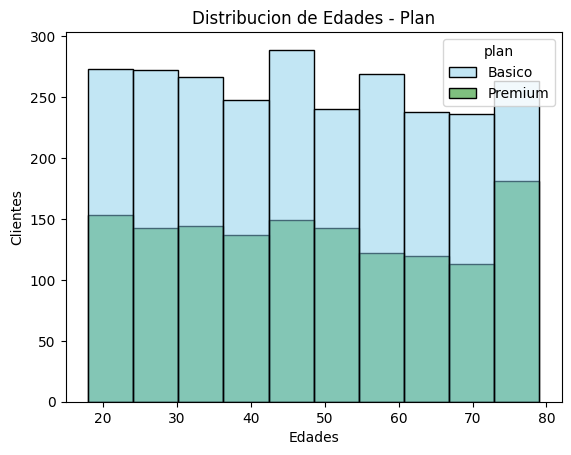

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de Edades - Plan')
plt.xlabel('Edades')
plt.ylabel('Clientes')
plt.show()

💡Insights: 
- Distribución simetrica, se observa que la cantidad de planes premium aumenta entre las edades de 70 - 80
- El plan basico es el mas contratado

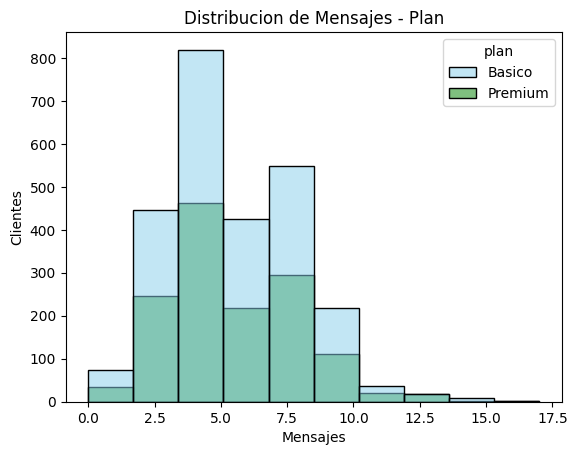

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de Mensajes - Plan')
plt.xlabel('Mensajes')
plt.ylabel('Clientes')
plt.show()

💡Insights: 
- Distribucion con sesgo a la derecha
- Usuarios con plan basico y premium tienden a utilizar 5 mensajes

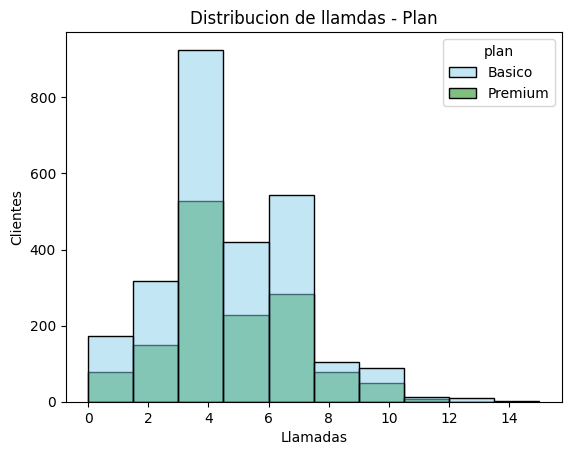

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de llamdas - Plan')
plt.xlabel('Llamadas')
plt.ylabel('Clientes')
plt.show()

💡Insights: 
- Distribución con sesgo a la derecha
- Usuarios con plan basico y premmium utilizan una cantidad similar de llamadas

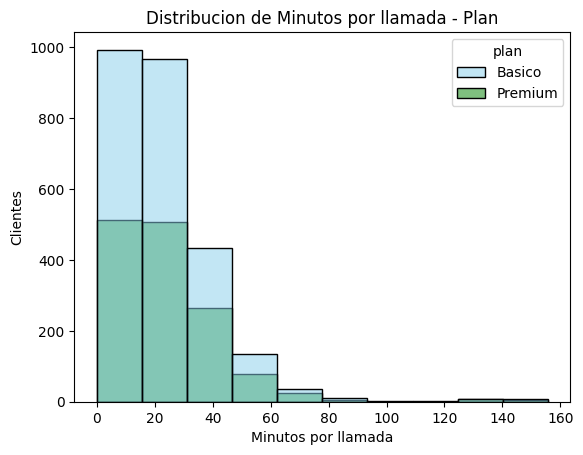

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de Minutos por llamada - Plan')
plt.xlabel('Minutos por llamada')
plt.ylabel('Clientes')
plt.show()

💡Insights: 
- Distribucion con sesgo a la derecha
- Usuarios con plan basico y premium tienen a durar sus llamadas entre 0 y 30 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

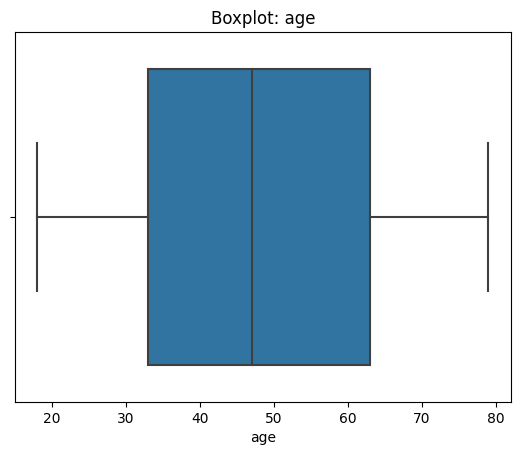

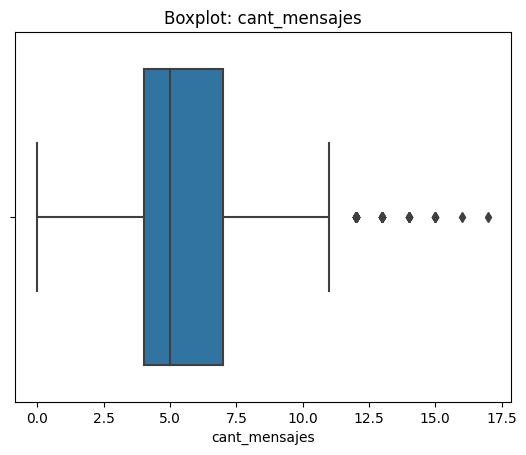

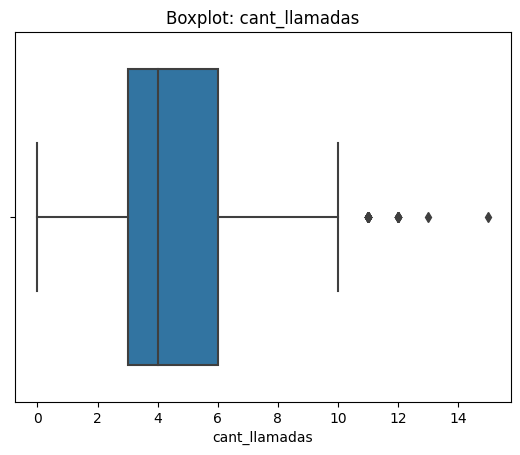

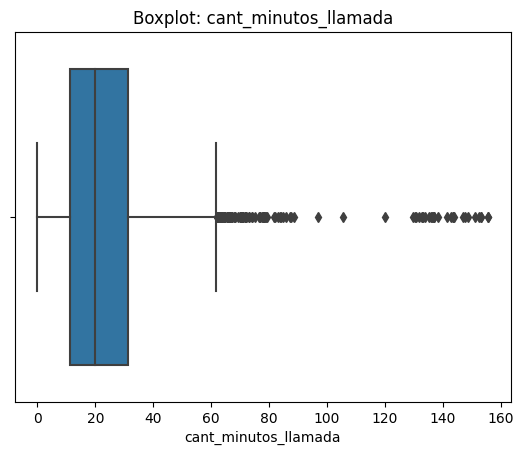

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [47]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(col)
    print('IQR:', IQR)

    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    display(user_profile[user_profile[col] > limite_superior])


cant_mensajes
IQR: 3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
315,10315,Carlos,Lopez,30.0,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13,3,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13,3,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12,5,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12,3,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12,1,2.24
539,10539,Sofia,Ramirez,77.0,Cali,2022-05-28 14:06:55.903975994,Basico,NaN,14,5,8.66
591,10591,Ana,Gomez,25.0,NaN,2022-06-11 19:50:27.456864216,Basico,NaN,12,2,16.52
670,10670,Carlos,Torres,47.0,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN,12,3,19.13
903,10903,Carlos,Lopez,63.0,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18",12,3,8.89
908,10908,Mariana,Lopez,56.0,MTY,2022-09-06 15:03:06.346586648,Basico,NaN,14,3,12.50


cant_llamadas
IQR: 3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
116,10116,Ana,Garcia,52.0,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3,11,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4,12,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4,12,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8,11,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4,15,78.11
1013,11013,Mateo,Lopez,65.0,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN,4,11,60.83
1563,11564,Carlos,Lopez,41.0,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN,8,11,30.17
1613,11614,Mateo,Garcia,73.0,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN,5,11,41.80
1911,11912,Mariana,Garcia,48.0,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN,2,11,65.71
2012,12013,Mateo,Lopez,48.0,GDL,2023-07-06 04:43:01.845461368,Basico,NaN,2,12,65.55


cant_minutos_llamada
IQR: 20.295


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8,7,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6,5,152.36
93,10093,Ana,Torres,67.0,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2,7,71.57
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9,4,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8,9,78.77
...,...,...,...,...,...,...,...,...,...,...,...
3919,13920,Mariana,Lopez,48.0,Bogotá,2024-12-09 08:50:24.756189056,Premium,NaN,4,5,132.72
3926,13927,Mariana,Lopez,18.0,GDL,2024-12-11 06:50:30.157539392,Basico,"1,72549E+18",8,4,135.96
3944,13945,Luis,Ramirez,30.0,Bogotá,2024-12-16 05:07:52.618154544,Basico,NaN,7,3,133.97
3952,13953,Mateo,Gomez,58.0,GDL,2024-12-18 09:42:15.933983504,Basico,NaN,0,7,155.69


In [45]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
- Mantendria todos los outliers, porque son casos raros, pero son posibles, ademas de que podrian ser un segmento de clientes que podemos catalogar como premium

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso
def segmentacion_clientes_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas <= 5 and mensajes <= 5:
            return 'Bajo uso'

    elif llamadas <= 10 and mensajes <= 10:
            return 'Uso medio'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentacion_clientes_uso, axis=1)

In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,pd.NA,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


In [60]:
user_profile['grupo_uso'].value_counts() # revisando cuantos clientes hay por categoriaed

Uso medio    2393
Bajo uso     1474
Alto uso      132
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [65]:
# Crear columna grupo_edad
def segmentacion_clientes_edad(row):
    edad = row['age']
    
    if edad <= 30:
        return 'Joven'

    if edad <= 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(segmentacion_clientes_edad, axis=1)

In [66]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,pd.NA,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Uso medio,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Bajo uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


In [67]:
user_profile['grupo_edad'].value_counts() # revisando cuantos clientes hay por edad

Adulto          2007
Adulto Mayor    1151
Joven            841
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

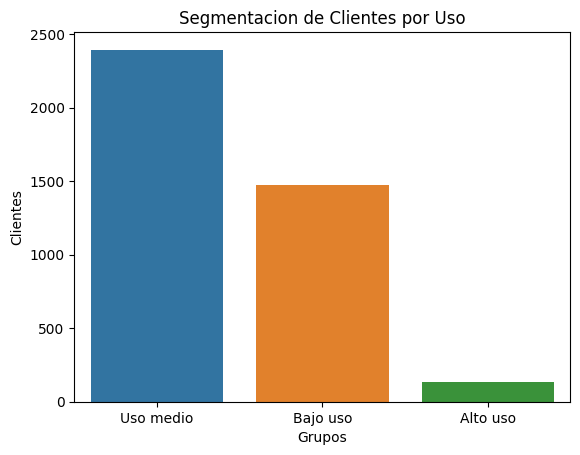

In [70]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Segmentacion de Clientes por Uso')
plt.xlabel('Grupos')
plt.ylabel('Clientes')
plt.show()

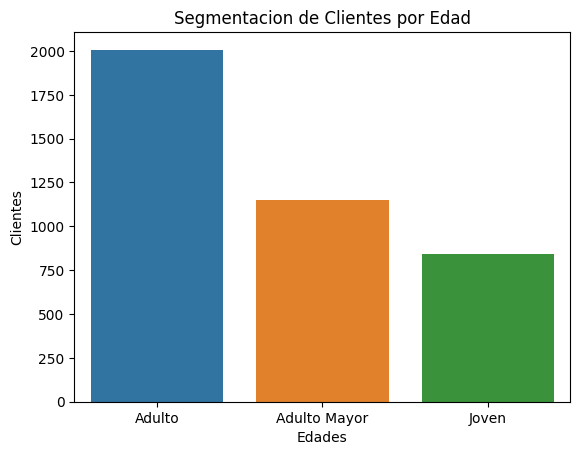

In [71]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Segmentacion de Clientes por Edad')
plt.xlabel('Edades')
plt.ylabel('Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- Tenia valores nulos, valores invalidos, fechas futuras, churn date con un 88% de valores nulos
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- El nivel de uso medio es el mas utilizado y y adulto es la mayor concentracion de clientes  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- El grupo de alto uso tienden a utilizar mas llamdas y mensajes y el adulto mayor contratan mas planes premium
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- Es una cantidad minima, vale la pena mantenerlos, ya que sus consumos son muy altos, pero son posibles


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Diseñar un plan intermedio entre basico y premium, tener algun tipo de plan para llamadas y mensajes ilimitados

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores Nulos
- Fechas Futuras
- Valores invalidos, sentinel(-999)
- churn date con 88% de valores nulos, pero no es un erros, me dice si los clientes siguen activos


🔍 **Segmentos por Edad**
- Joven - grupo mas pequeño
- Adulto - grupo mayoritario
- Adulto mayor - grupo intermedio


📊 **Segmentos por Nivel de Uso**
- Uso bajo es el intermedio
- Uso medio representa la mayoria
- Uso Alto es el minoritario


➡️ Esto sugiere que ...
El la mayoria de clientes representa el uso medio con planes basicos y el de uso alto a pesar de ser el grupo minoritario con planes premium son lo que estan dispuesto a pagar mas


💡 **Recomendaciones**
- disñar plan intermedio para ofrecer al grupor de plan basico (que es la mayoria de clientes) a este plan
- diseñar algun plan ilimatado para el grupo de alto consumo

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`